## 1. Load the data

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_DIR = Path.cwd().resolve().parent
DATA = PROJECT_DIR / "data"
OUTPUT = PROJECT_DIR / "results" / "simple_baseline"
OUTPUT.mkdir(parents=True, exist_ok=True)

pipes = pd.read_csv(DATA / 'pipes.csv')
leaks = pd.read_csv(DATA / 'train.csv', usecols=['Pipe ID'])
print('Pipes:', len(pipes))
print('Historical leak records:', len(leaks))

Pipes: 43039
Historical leak records: 14113


## 2. Inspection


In [17]:
pipes = pipes[['Pipe ID', 'Lay date', 'Material', 'Surface',
               'GPS x1', 'GPS y1', 'GPS x2', 'GPS y2']].copy()
pipes.columns = ['id', 'date', 'material', 'surface', 'x1', 'y1', 'x2', 'y2']
pipes['date'] = pd.to_datetime(pipes['date'])
pipes.head()

,id,date,material,surface,x1,y1,x2,y2
0,P01001,1955-03-11,copper,grassland,6136.29,5020.97,6124.15,5020.97
1,P01002,1971-09-19,cast iron,water,6512.35,4147.58,6536.59,4201.94
2,P01003,1971-09-18,cast iron,water,6536.59,4201.94,6518.42,4201.93
3,P01004,1982-05-22,cast iron,structure,2836.68,3377.95,2848.80,3405.12
4,P01005,1971-07-03,cast iron,water,5117.28,4272.91,5126.37,4297.16


In [18]:
# Count missing values. We do not drop these pipes.
pipes.isna().sum()

id           0
date        15
material     8
surface      0
x1           0
y1           0
x2           0
y2           0
dtype: int64

In [19]:
pipes.material.unique()

<StringArray>
[      'copper',    'cast iron',    'gray iron', 'wrought iron',
        'brass', 'polyurethane',            nan]
Length: 7, dtype: str

In [20]:
leaks.head()

,Pipe ID
0,P19711
1,P07628
2,P31195
3,P15715
4,P10415


### 2.1 Work out which pipes have already been replaced
A pipe in the historical leak file was already replaced with polyurethane.

Keep both the original and current materials. 

Use past leak IDs only to build the known 2027 state, not to choose a model from held-out repair costs. For earlier-year validation, must reconstruct the state using only leaks known at that earlier date.

In [21]:
iron_types = ['cast iron', 'gray iron', 'wrought iron']
pipes['current_material'] = pipes['material'].fillna('unknown')
pipes


,id,date,material,surface,x1,y1,x2,y2,current_material
0,P01001,1955-03-11,copper,grassland,6136.29,5020.97,6124.15,5020.97,copper
1,P01002,1971-09-19,cast iron,water,6512.35,4147.58,6536.59,4201.94,cast iron
2,P01003,1971-09-18,cast iron,water,6536.59,4201.94,6518.42,4201.93,cast iron
3,P01004,1982-05-22,cast iron,structure,2836.68,3377.95,2848.80,3405.12,cast iron
4,P01005,1971-07-03,cast iron,water,5117.28,4272.91,5126.37,4297.16,cast iron
...,...,...,...,...,...,...,...,...,...
43034,P44035,1971-07-12,cast iron,water,4791.94,4288.78,4797.85,4334.63,cast iron
43035,P44036,1971-07-05,cast iron,water,4957.39,4288.78,4951.48,4334.63,cast iron
43036,P44037,1971-07-06,cast iron,water,4957.39,4288.78,4963.30,4242.93,cast iron
43037,P44038,1971-07-11,cast iron,water,4957.39,4105.39,4963.30,4151.24,cast iron


In [22]:
already_leaked = pipes['id'].isin(leaks['Pipe ID'])
already_leaked

0        False
1         True
2         True
3        False
4         True
         ...  
43034    False
43035     True
43036    False
43037    False
43038    False
Name: id, Length: 43039, dtype: bool

In [ ]:
pipes.loc[already_leaked, 'current_material'] = 'polyurethane'

pipes['remaining_iron'] = pipes['current_material'].isin(iron_types)
pipes['target'] = pipes['material'].isin(iron_types) | pipes['material'].isna() ## whether if all iron pipes must be covered??
print(pipes.head())
print('Known iron pipes still needing replacement:', pipes['remaining_iron'].sum())
print('Conservative coverage targets:', pipes['target'].sum())

       id       date   material    surface       x1       y1       x2  \
0  P01001 1955-03-11     copper  grassland  6136.29  5020.97  6124.15   
1  P01002 1971-09-19  cast iron      water  6512.35  4147.58  6536.59   
2  P01003 1971-09-18  cast iron      water  6536.59  4201.94  6518.42   
3  P01004 1982-05-22  cast iron  structure  2836.68  3377.95  2848.80   
4  P01005 1971-07-03  cast iron      water  5117.28  4272.91  5126.37   

        y2 current_material  remaining_iron  target  
0  5020.97           copper           False   False  
1  4201.94     polyurethane           False    True  
2  4201.93     polyurethane           False    True  
3  3405.12        cast iron            True    True  
4  4297.16     polyurethane           False    True  
Known iron pipes still needing replacement: 26237
Conservative coverage targets: 38463


### 2.2. Calculate length and midpoint

In [27]:
pipes['length'] = np.sqrt((pipes['x2'] - pipes['x1'])**2 +
                          (pipes['y2'] - pipes['y1'])**2)
pipes['mid_x'] = (pipes['x1'] + pipes['x2']) / 2
pipes['mid_y'] = (pipes['y1'] + pipes['y2']) / 2

pipes[['id', 'length', 'mid_x', 'mid_y']].head()

,id,length,mid_x,mid_y
0,P01001,12.140000,6130.220,5020.970
1,P01002,59.519637,6524.470,4174.760
2,P01003,18.170003,6527.505,4201.935
3,P01004,29.750686,2842.740,3391.535
4,P01005,25.897695,5121.825,4285.035


### 2.3 Draw the pipe network
Every line is one pipe. Orange lines are known iron pipes still needing replacement in 2027. Gray lines are the other pipes, including the few with unknown material.


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

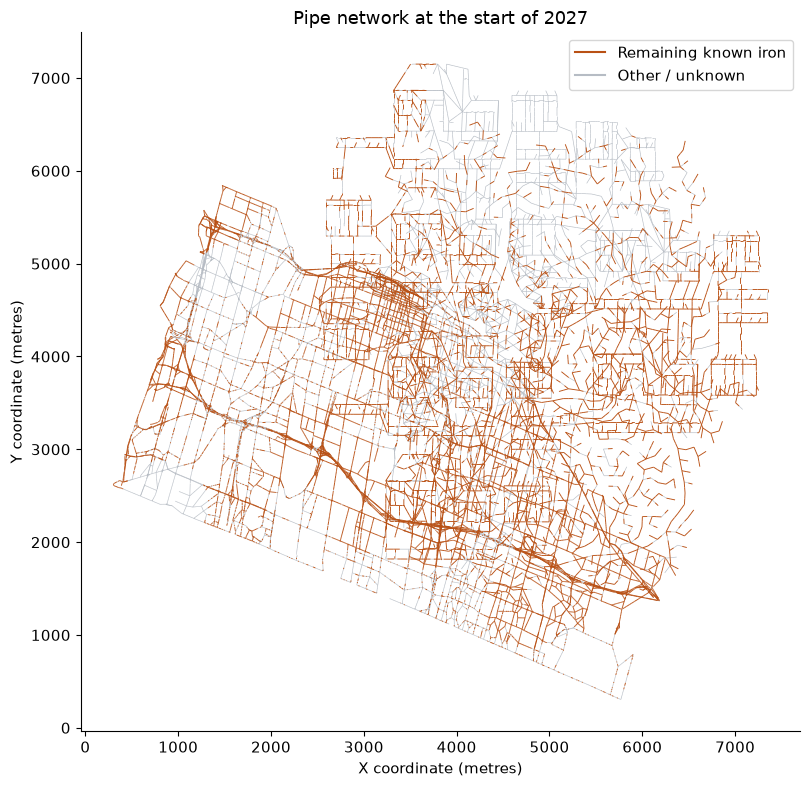

In [28]:
segments = np.stack([pipes[['x1', 'y1']].to_numpy(),
                     pipes[['x2', 'y2']].to_numpy()], axis=1)
is_iron = pipes['remaining_iron'].to_numpy()

plt.rcParams.update({'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})
fig, ax = plt.subplots(figsize=(10, 8))
ax.add_collection(LineCollection(segments[~is_iron], colors='#b6bcc4', linewidths=0.45))
ax.add_collection(LineCollection(segments[is_iron], colors='#b95014', linewidths=0.65))
ax.autoscale()
ax.set_aspect('equal')
ax.set(xlabel='X coordinate (metres)', ylabel='Y coordinate (metres)',
       title='Pipe network at the start of 2027')
ax.legend(handles=[Line2D([], [], color='#b95014', label='Remaining known iron'),
                   Line2D([], [], color='#b6bcc4', label='Other / unknown')])
fig.tight_layout()
fig.savefig(OUTPUT / 'pipe_network.png', dpi=160)
plt.show()

### 2.4. Put a circle around each target pipe

In [29]:
targets = pipes[pipes['target']].sort_values(['date', 'id'], na_position='last') # earliest to latestest lay

circles = pd.DataFrame({
    'pipe_id': targets['id'],
    'x': targets['mid_x'],
    'y': targets['mid_y'],
    'radius': targets['length'] / 2 + 0.00001 # some error for safety margin
}).reset_index(drop=True)

print('Number of circles:', len(circles))
circles.head()

Number of circles: 38463


,pipe_id,x,y,radius
0,P40093,3999.310,3588.215,4.089646
1,P17841,4774.630,1307.600,4.150347
2,P17842,4777.645,1313.455,2.437970
3,P17843,4774.460,1313.400,2.871421
4,P17844,4770.465,1317.520,2.874888


### 2.5. Choose one circle to understand it

A pipe belongs to this job only when **both endpoints are inside the circle**. A pipe crossing the boundary is not partially replaced.

In [43]:
import random
circle_number = random.randint(0,len(circles) - 1)
c = circles.iloc[circle_number]

distance1 = np.hypot(pipes['x1'] - c['x'], pipes['y1'] - c['y'])
distance2 = np.hypot(pipes['x2'] - c['x'], pipes['y2'] - c['y'])
inside = (distance1 <= c['radius']) & (distance2 <= c['radius'])

print('Circle number:', circle_number)
print('Radius:', round(c['radius'], 2), 'metres')
print('Fully contained pipes:', inside.sum())
pipes.loc[inside, ['id', 'current_material', 'surface', 'length']]

Circle number: 9900
Radius: 2.69 metres
Fully contained pipes: 1


,id,current_material,surface,length
14818,P15819,wrought iron,farmland,5.37908


In [ ]:
from matplotlib.patches import Circle
from matplotlib.lines import Line2D

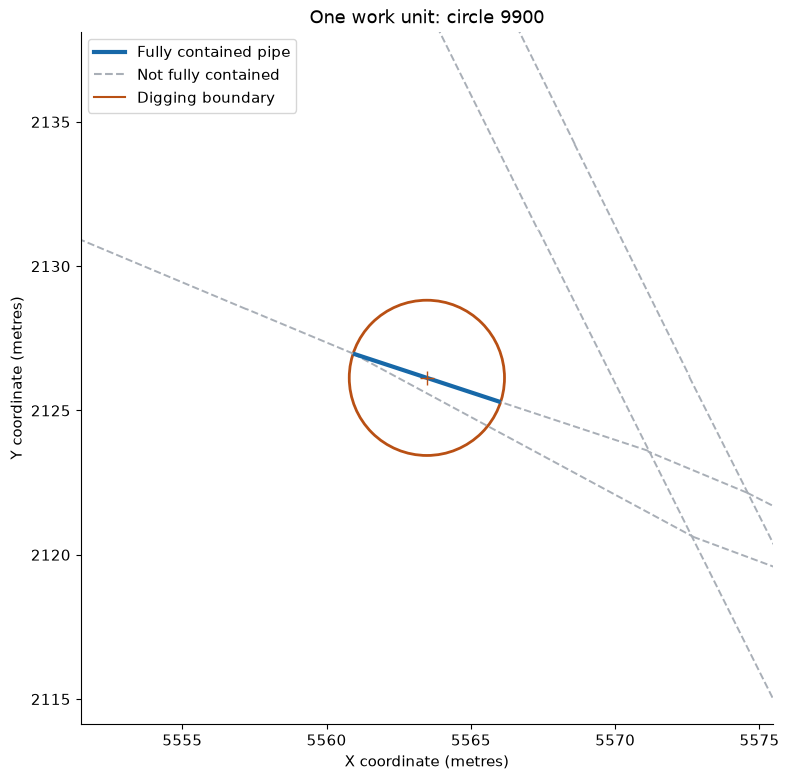

In [44]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.add_collection(LineCollection(segments[~inside], colors='#a9afb7', linewidths=1.4,
                                 linestyles='dashed'))
ax.add_collection(LineCollection(segments[inside], colors='#1768a8', linewidths=3))
ax.add_patch(Circle((c['x'], c['y']), c['radius'], fill=False,
                    edgecolor='#b95014', linewidth=2))
ax.plot(c['x'], c['y'], '+', color='#b95014', markersize=10)
zoom = max(c['radius'] * 1.7, 12)
ax.set_xlim(c['x'] - zoom, c['x'] + zoom)
ax.set_ylim(c['y'] - zoom, c['y'] + zoom)
ax.set_aspect('equal')
ax.set(xlabel='X coordinate (metres)', ylabel='Y coordinate (metres)',
       title=f'One work unit: circle {circle_number}')
ax.legend(handles=[Line2D([], [], color='#1768a8', linewidth=3, label='Fully contained pipe'),
                   Line2D([], [], color='#a9afb7', linestyle='--', label='Not fully contained'),
                   Line2D([], [], color='#b95014', label='Digging boundary')], loc='upper left')
fig.tight_layout()
fig.savefig(OUTPUT / 'one_circle.png', dpi=160)
plt.show()

## 3. Calculate the cost of the selected circle
This example uses material status at the start of 2027. The later budget loop will account for pipes replaced by earlier work units.

In [ ]:
surface_rates = {'grassland': 3, 'farmland': 7, 'swamp': 12,
                 'road': 17, 'structure': 50, 'water': 32}
contained = pipes[inside]
to_replace = contained[contained['current_material'] != 'polyurethane']

surface_rate = sum(surface_rates[s] for s in contained['surface'].unique())
area = np.pi * c['radius']**2
earthwork = (surface_rate * area)**0.85
pipe_cost = 200 * to_replace['length'].sum()
job_cost = round(100 + earthwork + pipe_cost, 2) if len(to_replace) else 0

print('Combined surface rate:', surface_rate)
print('Pipe length to replace:', round(to_replace['length'].sum(), 2), 'metres')
print('Cost of this job:', f'${job_cost:,.2f}')

           id       date      material   surface       x1       y1       x2  \
14818  P15819 1951-08-22  wrought iron  farmland  5560.92  2126.97  5566.03   

            y2 current_material  remaining_iron  target   length     mid_x  \
14818  2125.29     wrought iron            True    True  5.37908  5563.475   

         mid_y  
14818  2126.13  
Combined surface rate: 7
Pipe length to replace: 5.38 metres
Cost of this job: $1,250.18


### 4. Find the pipes inside every circle

In [50]:
from scipy.spatial import cKDTree

In [53]:
midpoints = pipes[['mid_x', 'mid_y']].to_numpy()
start_points = pipes[['x1', 'y1']].to_numpy()
end_points = pipes[['x2', 'y2']].to_numpy()
tree = cKDTree(midpoints)

# circle_members[0] will contain the row numbers of all pipes fully inside circle 0. 
# This avoids repeatedly searching all 43,039 pipes for every job.
circle_members = [] 

for row in circles.itertuples():
    center = np.array([row.x, row.y])
    nearby_rows = np.array(tree.query_ball_point(center, row.radius + 1e-8), dtype=int)
    d1 = np.linalg.norm(start_points[nearby_rows] - center, axis=1)
    d2 = np.linalg.norm(end_points[nearby_rows] - center, axis=1)
    members = nearby_rows[(d1 <= row.radius) & (d2 <= row.radius)]
    circle_members.append(members)

circle_members[1]


array([16840])

## 5. Execute the jobs using the yearly budget

In [ ]:
needs_work = (pipes['current_material'] != 'polyurethane').to_numpy()
lengths = pipes['length'].to_numpy()
surfaces = pipes['surface'].to_numpy()

annual_budget = 10_000_000 * 100
budget = annual_budget
year = 2027
records = []

for number, row in circles.iterrows():
    members = circle_members[number]
    replacing = members[needs_work[members]]
    if len(replacing) == 0:
        continue

    rate = sum(surface_rates[s] for s in set(surfaces[members]))
    earthwork = (rate * np.pi * row['radius']**2)**0.85
    pipe_cost = 200 * lengths[replacing].sum()
    cost_cents = round((100 + earthwork + pipe_cost) * 100)

    while cost_cents > budget:
        year += 1
        budget += annual_budget

    budget -= cost_cents
    needs_work = (pipes['current_material'] != 'polyurethane').to_numpy(copy=True)
    records.append({'circle': number, 'year': year,
                    'cost_cents': cost_cents, 'pipes_replaced': len(replacing)})

schedule = pd.DataFrame(records)
schedule['cost'] = schedule['cost_cents'] / 100
schedule.head()

,circle,year,cost_cents,pipes_replaced,cost
0,0,2027,254229,1,2542.29
1,1,2027,191561,1,1915.61
2,2,2027,113811,1,1138.11
3,3,2027,133168,1,1331.68
4,4,2027,133324,1,1333.24


## 6. Read the result

In [71]:
covered_rows

array([39092, 16840, 16841, ..., 11280, 11281, 11282], shape=(53804,))

In [68]:
total_cost = schedule['cost_cents'].sum() / 100
completion_year = int(schedule['year'].max())

print('Construction spending:', f'${total_cost:,.2f}')
print('Completion year:', completion_year)
print('25-year budget minus construction:', f'${250_000_000 - total_cost:,.2f}')

covered_rows = np.concatenate(circle_members)
uncovered = pipes[pipes['target'] & ~pipes.index.isin(covered_rows)]
print('Uncovered target pipes:', len(uncovered))

schedule.groupby('year')[['cost', 'pipes_replaced']].sum()

Construction spending: $179,904,553.15
Completion year: 2044
25-year budget minus construction: $70,095,446.85
Uncovered target pipes: 0


,cost,pipes_replaced
year,,
2027,9999994.17,3989
2028,9996506.45,3761
2029,10002530.81,4076
2030,9998992.08,3722
2031,9942244.48,3157
2032,10043293.96,481
2033,10013601.23,736
2034,9977949.66,1340
2035,10022793.37,2304


## 7. Save the candidate CSV

In [72]:
submission = pd.DataFrame({
    'center': circles.apply(lambda row: f"({row['x']:.8f}, {row['y']:.8f})", axis=1),
    'radius': circles['radius'].map(lambda radius: f'{radius:.8f}')
})
submission.to_csv(OUTPUT / 'simple_baseline_candidate.csv', index=False, header=False)
schedule.to_csv(OUTPUT / 'schedule.csv', index=False)
print('Saved files in:', OUTPUT)
submission.head()

Saved files in: /Users/simondoan/Documents/SFU/STAT 440/Project/P1/results/simple_baseline


,center,radius
0,"(3999.31000000, 3588.21500000)",4.08964629
1,"(4774.63000000, 1307.60000000)",4.15034734
2,"(4777.64500000, 1313.45500000)",2.43797021
3,"(4774.46000000, 1313.40000000)",2.87142080
4,"(4770.46500000, 1317.52000000)",2.87488826
